# Timing against the SVD
Time of the decomposition-free $\mathrm{Sgn}$ (generalized Newton–Schulz with the $\mathrm{bpoly}(D)$ profile, fixed $K_D$, power-iteration scaling) against the SVD-based one, over size $n$, $\sigma_{\min}$, device and $D$. Both routes get the same matrix; each of the `n_reps` repetitions uses a new random matrix of the same size and $\sigma_{\min}$, so the reported std is over matrices. Each timing is paired with the relative Frobenius error against the exact $\mathrm{Sgn}(M)$. Edit the config and rerun; set `devices=["cpu"]` without a GPU.

In [2]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.svd_timing import SvdTimingConfig, run_svd_timing, time_table, accuracy_table
%matplotlib inline

In [3]:
cfg = SvdTimingConfig(
    sizes=[128, 256, 512], smins=[1e-4], degrees=[1, 2, 3, 4],
    devices=["cpu", "cuda"], n_fixed=512, dtype=torch.float32, eps=None,
    power_iters=10, power_margin=1.1, n_warmup=3, n_reps=20, cpu_threads=None, svd_driver=None, seed=0,
)
res = run_svd_timing(cfg)

n=128 smin=0.0001: 20 matrices
  cpu: svd 1.36 ms | D=1 2.81 ms | D=2 2.57 ms | D=3 2.63 ms | D=4 2.94 ms
  cuda: svd 7.65 ms | D=1 6.44 ms | D=2 6.11 ms | D=3 6.44 ms | D=4 6.69 ms
n=256 smin=0.0001: 20 matrices
  cpu: svd 5.95 ms | D=1 10.10 ms | D=2 9.82 ms | D=3 8.61 ms | D=4 10.78 ms
  cuda: svd 22.65 ms | D=1 6.83 ms | D=2 5.94 ms | D=3 6.70 ms | D=4 6.62 ms
n=512 smin=0.0001: 20 matrices
  cpu: svd 25.00 ms | D=1 58.03 ms | D=2 55.26 ms | D=3 58.48 ms | D=4 62.95 ms
  cuda: svd 104.18 ms | D=1 14.43 ms | D=2 13.87 ms | D=3 14.55 ms | D=4 15.68 ms


time (s), median ± std over 20 matrices: cpu, smin = 0.0001
n    D=1                D=2                D=3                D=4                SVD              
128  0.00281 ± 0.00072  0.00257 ± 0.00084  0.00263 ± 0.00062  0.00294 ± 0.00086  0.00136 ± 0.00068
256  0.0101 ± 0.0036    0.00982 ± 0.0032   0.00861 ± 0.004    0.0108 ± 0.0035    0.00595 ± 0.0017 
512  0.058 ± 0.018      0.0553 ± 0.0028    0.0585 ± 0.0017    0.0629 ± 0.0019    0.025 ± 0.0015   

relative Frobenius error, mean ± std over 20 matrices, and iterations run K: cpu, smin = 0.0001
     K   n=128               n=256               n=512             
D=1  31  4.84e-05 ± 1.9e-06  6.56e-05 ± 1.5e-06  6.00e-05 ± 9.7e-07
D=2  20  3.73e-05 ± 1.7e-06  5.20e-05 ± 1.2e-06  4.91e-05 ± 4.5e-07
D=3  16  3.37e-05 ± 1.4e-06  4.60e-05 ± 1.3e-06  4.49e-05 ± 5.9e-07
D=4  14  3.08e-05 ± 1.2e-06  4.28e-05 ± 1.4e-06  4.22e-05 ± 4.0e-07
SVD  -   3.40e-05 ± 1.8e-06  3.43e-05 ± 1.2e-06  3.42e-05 ± 7.6e-07

time (s), median ± std over 20 matrice

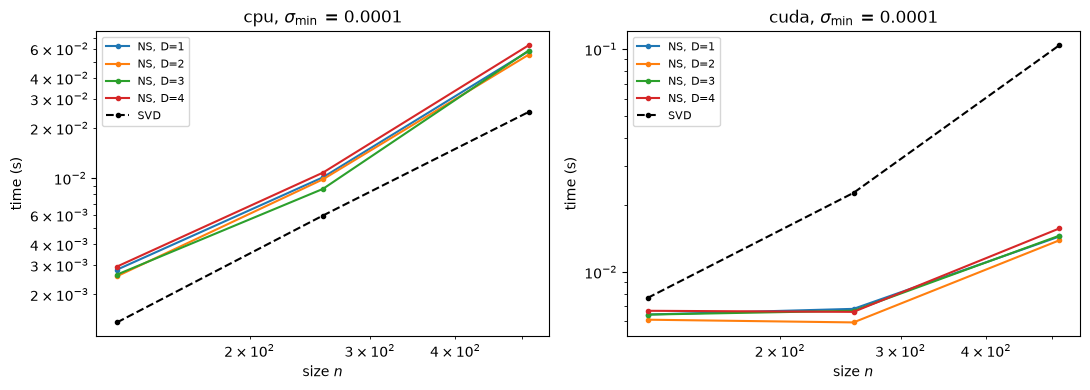

In [4]:
smin_plot = 1e-4  # sigma_min shown in the time-vs-size panels and the tables
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_size(res, device, smin_plot, ax=ax)
fig.tight_layout()
for device in res["cfg"].devices:
    time_table(res, device, smin_plot)
    print()
    accuracy_table(res, device, smin_plot)
    print()

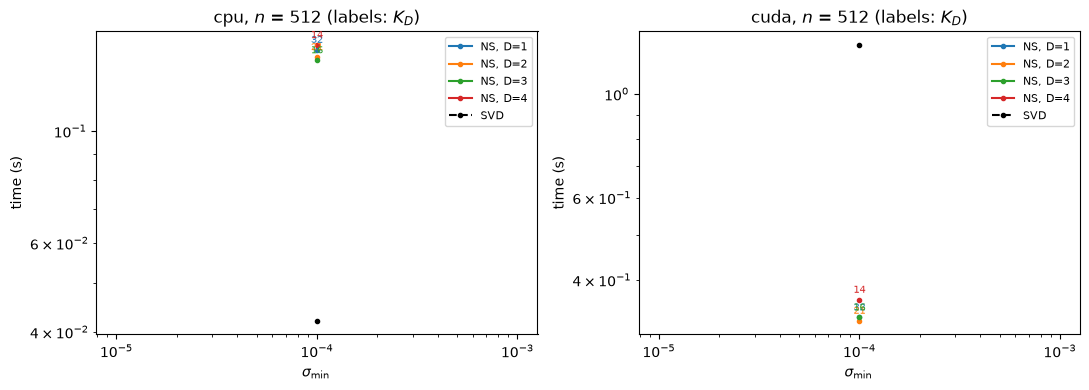

In [4]:
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_smin(res, device, ax=ax)
fig.tight_layout()